# Spatial Analysis

- Reconstruct predictions into 2D images using lat and lon indices
- Assess the results from specific case studies
- Compare results against truth and GSO optical flow

In [1]:
import xgboost as xgb
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path
import numpy as np
import dask.dataframe as dd

import sys
import yaml

sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import data_transform
from xgb_preprocess import prepare_data
from gso_preprocess import datetime_to_lead_time

# Load Model and Data

In [2]:
# READ PARQUET TABULAR DATA
data_path = Path('/scratch/er8/cd3022/xgb_datasets/')
df = pd.read_parquet(data_path / "test_months.parquet")

# Loop through model configs and add forecast to the DF
model_configs = [
    # 'original',
    'vanilla',
]
for config_name in model_configs:
    model = xgb.XGBRegressor()
    with open(f"/home/548/cd3022/repos/solar-nowcast/configs/mouse/{config_name}.yaml") as f:
        config = yaml.safe_load(f)

    # Get model configurations from the yaml file
    model_name = config["model"]["name"]
    forecast_lead = config["model"]["forecast_lead"]
    X_vars = config["data"]["predictors"]
    target = config["data"]["target"]
    y_var = f'{target}_t{forecast_lead}'

    # Load the corresponding trained model
    model.load_model(f"/scratch/er8/cd3022/xgb_models/{model_name}.json")
    
    # Get X and y variables
    X, y = prepare_data(
        df=df,
        X=X_vars,
        y=y_var,
    )

    # Make predictions with the model, and add to the DF
    df[f'forecast_{model_name}'] = model.predict(X)

# ds_xgb = df.to_xarray()

In [3]:
model_name = 'vanilla_no_log'

# Load the corresponding trained model
model.load_model(f"/scratch/er8/cd3022/xgb_models/{model_name}.json")

# Make predictions with the model, and add to the DF
df[f'forecast_{model_name}'] = model.predict(X)

In [4]:
ds_xgb = df.to_xarray()

In [7]:
gso_files = []
for day in [1, 4, 5]:
        gso_path = Path(f'/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/02/{day:02d}')
        gso_files.extend([f for f in gso_path.glob('*.nc')])
    
ds_gso = xr.open_mfdataset(
    gso_files,
    preprocess=datetime_to_lead_time,
    combine='nested',
    concat_dim='time',
    parallel=True,
    chunks='auto'
)

In [26]:
ds_gso = ds_gso.sel(
    latitude=ds_xgb.latitude,
    longitude=ds_xgb.longitude
)

In [8]:
ds_gso['cloud_optical_depth_log'] = data_transform.log_transform(ds_gso['cloud_optical_depth'])

In [13]:
ds_xgb['forecast_vanilla_inv'] = data_transform.inverse_log_transform(ds_xgb['forecast_vanilla'])

Text(0.5, 1.0, 'XGB no transform')

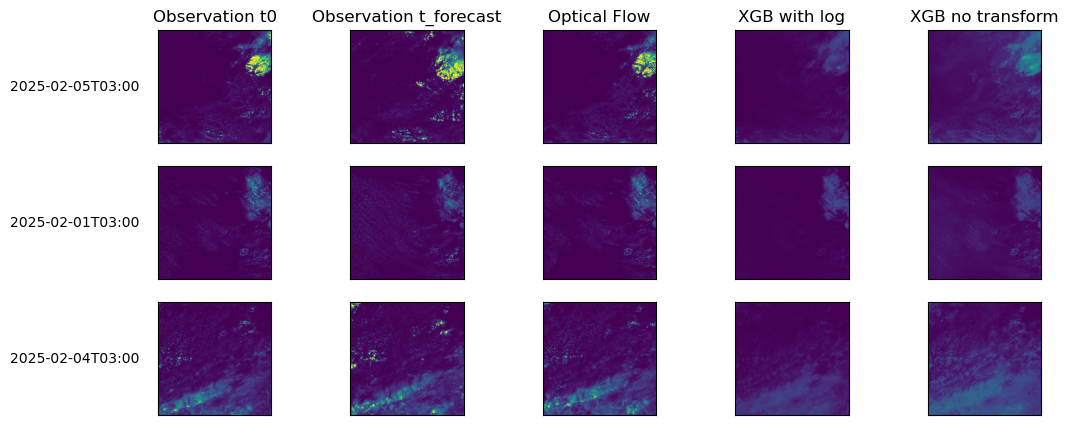

In [50]:
times = ['2025-02-05T03:00', '2025-02-01T03:00', '2025-02-04T03:00']
nrows = len(times)


f_time = '01:00:00'

vmin=0
vmax=100

fig, ax = plt.subplots(nrows=nrows, ncols=5, figsize=(12,5))
for i, t in enumerate(times):
    ax[i,0].set_ylabel(t, rotation=0, labelpad=60, va='center')
    ax[i,0].imshow(
        ds_xgb.cloud_optical_depth.sel(time=t),
        vmin=vmin, vmax=vmax
    )
    ax[i,1].imshow(
        ds_xgb.cloud_optical_depth_t1.sel(time=t),
        vmin=vmin, vmax=vmax
    )
    
    ax[i,2].imshow(
        ds_gso.cloud_optical_depth.sel(time=t, forecast_time=f_time),
        vmin=vmin, vmax=vmax
    )
    
    ax[i,3].imshow(
        ds_xgb.forecast_vanilla_inv.sel(time=t),
        vmin=vmin, vmax=vmax
    )
    
    ax[i,4].imshow(
        ds_xgb.forecast_vanilla_no_log.sel(time=t),
        vmin=vmin, vmax=vmax
    )
    for j in range(5):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

ax[0,0].set_title('Observation t0')
ax[0,1].set_title('Observation t_forecast')
ax[0,2].set_title('Optical Flow')
ax[0,3].set_title('XGB with log')
ax[0,4].set_title('XGB no transform')